# Mejora del Tracking de IDs — VEO Pipeline

Comparativa entre KalmanFieldTracker V1 (baseline), V2 (Hungarian + Re-ID) y StrongKalmanTrackerV3. Cuantifica la reduccion de fragmentacion de IDs.

## Requisitos externos
- **Video panoramico VEO** (`data/videos/veo_panoramico_banyoles_1aParte.mp4`) — descargar con yt-dlp
- **Modelo YOLO jugadores** (`MODEL_PATH` en CONFIG) — entrenar con `train_yolo.py`
- **Homografias**: si no existen, carga automaticamente `data/example_banyoles/H_camA.npy` y `H_camB.npy`
- **PKL prototipos**: si no existen, carga automaticamente `data/example_banyoles/prototypes_day.pkl`


# 🎯 Mejora del Tracking de IDs — VEO Pipeline

**Objetivo:** comparar el `KalmanFieldTracker` actual (V1) con `KalmanFieldTrackerV2`, que incorpora:

| Mejora | Detalle |
|---|---|
| **Hungarian assignment** | `scipy.optimize.linear_sum_assignment` en lugar de greedy |
| **Hue Re-ID** | usa `hue_sig_distance` para re-identificar tras oclusiones largas |
| **Tracks tentativos** | un track se emite solo tras ≥ N detecciones confirmadas |
| **hue_sig en dets** | cada detección incluye el descriptor hue para Re-ID inmediata |

El notebook genera métricas cuantitativas (IDs creados, ghost tracks, teleportaciones)  
y visualizaciones interactivas para comparar antes/después.

In [1]:
# ════════════════════════════════════════════════════
#  CONFIGURACIÓN — edita aquí
# ════════════════════════════════════════════════════
VIDEO_PATH     = "data/videos/veo_panoramico_banyoles_1aParte.mp4"
PKL_DAY_PATH   = "prototypes_v3_day.pkl"
PKL_NIGHT_PATH = "prototypes_v3_night.pkl"
MODEL_PATH     = "runs/detect/modelo_players_v24_panoramic2/weights/best.pt"
H_A_PATH       = "data/calib_alpha1/calib_camA_alpha1_homography.npy"
H_B_PATH       = "data/calib_alpha1/calib_camB_alpha1_homography.npy"

START_FRAME = 8000
N_FRAMES    = 600     # 20 s a 30 fps — aumenta para más estadísticas
CONF        = 0.50

# ── Parámetros tracker V1 (baseline)
V1_MAX_DIST  = 6.0
V1_WINDOW_S  = 7.0
V1_CLASS_W   = 8.0

# ── Parámetros tracker V2 (mejorado) — se tunan en la celda interactiva
V2_MAX_DIST         = 6.0
V2_WINDOW_S         = 7.0
V2_CLASS_W          = 8.0
V2_MIN_HITS_CONFIRM = 3
V2_HUE_REID_W       = 5.0
V2_GAP_HUE_FRAMES   = 8

# ── Métricas
TELEPORT_M   = 8.0
MIN_HITS_GHO = 8
# ── Parámetros tracker V3 (StrongKalman + class-cap)
V3_HIGH_CONF  = 0.50   # umbral stage 1
V3_LOW_CONF   = 0.35   # umbral stage 2 (= CONF)
V3_LOST_S     = 2.0    # segundos en estado lost
V3_GAP_HUE    = 5      # frames sin match para usar hue_sig
V3_HUE_W      = 4.0    # peso hue (metros equivalentes)
V3_MAX_TOTAL  = 25     # cap total jugadores en campo
V3_MAX_CLASS  = {'player_home':10,'player_away':10,
                  'gk_home':1,'gk_away':1,'referee':3}
# -- Fallbacks a datos de ejemplo ----------------------------------
import os as _os
if not _os.path.exists(PKL_DAY_PATH):   PKL_DAY_PATH   = "data/example_banyoles/prototypes_day.pkl"
if not _os.path.exists(PKL_NIGHT_PATH): PKL_NIGHT_PATH = "data/example_banyoles/prototypes_night.pkl"
if not _os.path.exists(H_A_PATH):        H_A_PATH       = "data/example_banyoles/H_camA.npy"
if not _os.path.exists(H_B_PATH):        H_B_PATH       = "data/example_banyoles/H_camB.npy"


In [2]:
%matplotlib inline
import sys, cv2, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import ipywidgets as widgets
from IPython.display import display, clear_output
from collections import defaultdict
from pathlib import Path
from scipy.optimize import linear_sum_assignment

warnings.filterwarnings("ignore")

sys.path.insert(0, str(Path.cwd()))
from pipeline_core import (
    preprocess_half, init_undistort_maps,
    get_grass_hue, get_torso_crop, get_player_color,
    get_hue_signature, get_hue_signature_masked,
    extract_sam_masks_batch, classify_player_v3, classify_player,
    hue_sig_distance, _HUE_BINS,
    pixel_to_field, esquinas_metros,
    _unify_seam, _global_nms,
    select_protos, draw_pitch_mpl,
    GAP_COLOR_FRAMES, COLOR_WEIGHT_M, MIN_HITS_CLASS,
    MIN_CONF_NEW_UNKNOWN, L_M, A_M, ESCALA,
    CLASSES_ORDER, COLOR_MAP_HEX, DARK_BG,
    SEAM_MARGIN_M, SEAM_FUSION_M, GLOBAL_NMS_M, MAX_DETS_FRAME,
    KalmanFieldTracker,
)
from ultralytics import YOLO

init_undistort_maps()

plt.rcParams.update({
    'figure.facecolor': '#0f0f1a', 'axes.facecolor': '#16213e',
    'text.color': 'white', 'axes.labelcolor': 'white',
    'xtick.color': '#aab', 'ytick.color': '#aab', 'axes.edgecolor': '#334'
})
print(" Imports OK")

✅ Imports OK


In [3]:
# ─────────────────────────────────────────────────────
#  Cargar modelos, homografías y PKL
# ─────────────────────────────────────────────────────
print(" Cargando YOLO...")
model = YOLO(MODEL_PATH)

with open(PKL_DAY_PATH,   'rb') as f: protos_day   = pickle.load(f)
with open(PKL_NIGHT_PATH, 'rb') as f: protos_night = pickle.load(f)
is_v3 = any('hue_sig' in p for p in protos_day.values())
print(f" PKL día: {list(protos_day.keys())} (v3={is_v3})")
print(f" PKL noche: {list(protos_night.keys())}")

H_a = np.load(H_A_PATH)
H_b = np.load(H_B_PATH)

cap_info = cv2.VideoCapture(VIDEO_PATH)
FPS       = cap_info.get(cv2.CAP_PROP_FPS) or 30.0
VID_W     = int(cap_info.get(cv2.CAP_PROP_FRAME_WIDTH))
VID_H     = int(cap_info.get(cv2.CAP_PROP_FRAME_HEIGHT))
N_TOTAL   = int(cap_info.get(cv2.CAP_PROP_FRAME_COUNT))
cap_info.release()

HALF_H  = VID_H // 2
END_F   = min(START_FRAME + N_FRAMES, N_TOTAL)

init_undistort_maps(half_h=HALF_H, vid_w=VID_W)

corners_a = esquinas_metros(H_a, VID_W, HALF_H)
corners_b = esquinas_metros(H_b, VID_W, HALF_H)
LIMITE_X  = float(np.mean([corners_a[:, 0].max(), corners_b[:, 0].min()]))

print(f" {VID_W}×{VID_H} {FPS:.1f}fps {N_TOTAL} frames")
print(f" Límite costura: {LIMITE_X:.1f} m | Segmento: {START_FRAME}–{END_F} ({N_FRAMES/FPS:.1f}s)")

📦 Cargando YOLO...
📋 PKL día:   ['player_home', 'player_away', 'referee', 'gk_away', 'gk_home']  (v3=True)
📋 PKL noche: ['player_home', 'player_away', 'referee', 'gk_home']
🎬 1080×1080  30.0fps  82255 frames
🗺️  Límite costura: 62.8 m  |  Segmento: 8000–8600  (20.0s)


In [4]:
# ─────────────────────────────────────────────────────
#  Helper: detectar en una mitad + enriquecer con hue_sig
# ─────────────────────────────────────────────────────
def detect_half(model_inst, half_img, H, protos_local, conf=CONF, sam=None):
    results = model_inst.predict(half_img, conf=conf, verbose=False)
    dets = []
    if not results or results[0].boxes is None:
        return dets

    boxes_np  = results[0].boxes.xyxy.cpu().numpy()
    confs_np  = results[0].boxes.conf.cpu().numpy()
    bboxes_l  = [(int(b[0]),int(b[1]),int(b[2]),int(b[3])) for b in boxes_np]
    sam_masks = extract_sam_masks_batch(half_img, bboxes_l, sam)
    gh        = get_grass_hue(half_img) or 55.0

    for idx_b, (box, conf_v) in enumerate(zip(boxes_np, confs_np)):
        x1,y1,x2,y2 = float(box[0]),float(box[1]),float(box[2]),float(box[3])
        crop = half_img[max(0,int(y1)):int(y2), max(0,int(x1)):int(x2)]
        if crop.size == 0:
            continue
        mask  = sam_masks[idx_b] if idx_b < len(sam_masks) else None
        torso = get_torso_crop(crop)

        if is_v3:
            cls_name,_,_,_ = classify_player_v3(crop, protos_local, grass_hue=gh, mask=mask)
        else:
            cls_name,_ = classify_player(torso, protos_local, gh)

        _, color_mean, _ = get_player_color(torso)
        hue_s = (get_hue_signature_masked(crop, mask, gh)
                 if (is_v3 and mask is not None)
                 else (get_hue_signature(torso, gh) if is_v3 else None))

        try:
            xm,ym = pixel_to_field((x1+x2)/2, float(y2), H)
        except Exception:
            xm,ym = None,None

        dets.append({
            'bbox_px':    (int(x1),int(y1),int(x2),int(y2)),
            'conf':       float(conf_v),
            'conf_yolo':  float(conf_v),
            'cls':        cls_name,
            'pos_m':      (xm,ym) if xm is not None else None,
            'color_desc': color_mean.tolist(),
            'hue_sig':    hue_s.tolist() if hue_s is not None else None,
        })
    return dets


def run_segment(tracker_obj, start=START_FRAME, n=N_FRAMES, verbose=True):
    cap = cv2.VideoCapture(VIDEO_PATH)
    cap.set(cv2.CAP_PROP_POS_FRAMES, start)
    frame_records = []

    for n_proc in range(n):
        ret, frame = cap.read()
        if not ret:
            break
        fidx = start + n_proc
        # Seleccionar PKL según iluminación del frame
        protos_cur = select_protos(frame, protos_day, protos_night)

        dets_a = detect_half(model, preprocess_half(frame[:HALF_H,:],'left'),  H_a, protos_cur)
        dets_b = detect_half(model, preprocess_half(frame[HALF_H:,:],'right'), H_b, protos_cur)

        unified = _unify_seam(
            [{**d,'cam':'A'} for d in dets_a],
            [{**d,'cam':'B'} for d in dets_b],
            cut_x=LIMITE_X)
        unified = _global_nms(unified)

        tracked = tracker_obj.update(fidx, unified)

        for d in tracked:
            if d['pos_m'] is None: continue
            xm,ym = d['pos_m']
            if not (0 <= xm <= L_M and 0 <= ym <= A_M): continue
            frame_records.append({
                'frame':    fidx,
                'gid':      d['gid'],
                'cls':      d['cls'],
                'x_m':      round(xm,2),
                'y_m':      round(ym,2),
                'conf':     round(d['conf'],3),
                'speed_ms': round(d.get('speed_ms',0.0),2),
                'cam':      d.get('cam','?'),
            })

        if verbose and (n_proc+1) % 150 == 0:
            pct = 100*(n_proc+1)/n
            print(f"  [{pct:.0f}%] frame {fidx}  IDs activos: {len(tracker_obj.active_ids())}")

    cap.release()
    return frame_records, tracker_obj

In [5]:
print(" Procesando con tracker V1 (baseline)...")
tracker_v1 = KalmanFieldTracker(fps=FPS,
                                  max_dist_m=V1_MAX_DIST,
                                  window_s=V1_WINDOW_S,
                                  class_weight=V1_CLASS_W)
records_v1, tracker_v1 = run_segment(tracker_v1)
df_v1 = pd.DataFrame(records_v1)
if len(df_v1):
    df_v1['time_s'] = (df_v1['frame'] - START_FRAME) / FPS

print(f"\n V1 completado")
print(f"   Registros: {len(df_v1)}  |  IDs únicos: {df_v1['gid'].nunique() if len(df_v1) else 0}")

🔄 Procesando con tracker V1 (baseline)...
  [25%] frame 8149  IDs activos: 9
  [50%] frame 8299  IDs activos: 8
  [75%] frame 8449  IDs activos: 2
  [100%] frame 8599  IDs activos: 4

✅ V1 completado
   Registros: 646  |  IDs únicos: 14


## KalmanFieldTrackerV2 — mejoras implementadas

### Cambios clave vs V1

**1. Hungarian assignment (scipy)**  
La V1 usa un bucle greedy: la primera detección con menor coste se lleva el track, sin garantía de óptimo global. Con Hungarian, se minimiza el coste total de todas las asignaciones a la vez. Especialmente importante cuando varios jugadores se cruzan simultáneamente.

**2. Hue Re-ID**  
Cada track almacena un `hue_sig` actualizado por EMA. Cuando el track lleva ≥ `gap_hue_frames` frames sin detección, el coste de aparearle una nueva detección incluye `hue_sig_distance × hue_reid_w`. Mucho más discriminativo que BGR para camisetas de colores distintos en condiciones de luz variable.

**3. Tracks tentativos**  
Un track nuevo **no se emite** al output hasta acumular `min_hits_confirm` detecciones consecutivas. Elimina ghost tracks generados por falsos positivos aislados (espectadores, árbitros de línea, sombras).

In [6]:
# ─────────────────────────────────────────────────────
#  KalmanFieldTrackerV2
#  Hungarian + Hue Re-ID + Tracks tentativos
# ─────────────────────────────────────────────────────
MIN_HITS_CONFIRM_V2 = V2_MIN_HITS_CONFIRM


class _KFTrackV2:
    def __init__(self, gid, pos_m, cls, conf, frame_idx,
                 color_desc=None, hue_sig=None, fps=30.0):
        self.gid          = gid
        self.conf         = conf
        self.last_frame   = frame_idx
        self.created      = frame_idx
        self.hits         = 1
        self.fps          = fps
        self.is_confirmed = False
        self.class_history = defaultdict(int)
        self.class_history[cls] += 1
        self.cls        = cls
        self._alpha     = 0.15
        self.color_desc = (np.array(color_desc, dtype=np.float32)
                           if color_desc is not None else None)
        self.hue_sig    = (np.array(hue_sig, dtype=np.float32)
                           if hue_sig is not None else None)
        dt = 1.0
        self.kf = cv2.KalmanFilter(4, 2)
        self.kf.transitionMatrix    = np.array([[1,0,dt,0],[0,1,0,dt],
                                                 [0,0,1,0],[0,0,0,1]], dtype=np.float32)
        self.kf.measurementMatrix   = np.array([[1,0,0,0],[0,1,0,0]], dtype=np.float32)
        self.kf.processNoiseCov     = np.diag([0.05,0.05,0.5,0.5]).astype(np.float32)
        self.kf.measurementNoiseCov = np.eye(2, dtype=np.float32) * 0.3
        self.kf.errorCovPost        = np.eye(4, dtype=np.float32)
        self.kf.statePost           = np.array([[pos_m[0]],[pos_m[1]],
                                                 [0.],[0.]], dtype=np.float32)

    def predict(self):
        s = self.kf.predict()
        return np.array([float(s[0,0]), float(s[1,0])], dtype=np.float32)

    def correct(self, pos_m, cls, conf, frame_idx, color_desc=None, hue_sig=None):
        self.kf.correct(np.array([[pos_m[0]],[pos_m[1]]], dtype=np.float32))
        self.last_frame = frame_idx
        self.hits      += 1
        self.conf       = conf
        if self.hits >= MIN_HITS_CONFIRM_V2:
            self.is_confirmed = True
        if cls != 'unknown':
            self.class_history[cls] += 1
            self.cls = max(self.class_history.items(), key=lambda kv: kv[1])[0]
        def _ema(cur, new):
            if new is None: return cur
            v = np.array(new, dtype=np.float32)
            return v if cur is None else (1 - self._alpha) * cur + self._alpha * v
        self.color_desc = _ema(self.color_desc, color_desc)
        self.hue_sig    = _ema(self.hue_sig,    hue_sig)

    def hue_dist(self, hue_sig_det, w) -> float:
        if self.hue_sig is None or hue_sig_det is None: return 0.0
        return min(hue_sig_distance(self.hue_sig, hue_sig_det) * w, w)

    def color_dist_bgr(self, color_desc, w=COLOR_WEIGHT_M) -> float:
        if self.color_desc is None or color_desc is None: return 0.0
        raw = float(np.linalg.norm(
            self.color_desc - np.array(color_desc, dtype=np.float32)))
        return min(raw / 441.0 * w, w)

    @property
    def pos(self):
        return np.array([float(self.kf.statePost[0,0]),
                         float(self.kf.statePost[1,0])], dtype=np.float32)

    @property
    def speed_ms(self):
        vx = float(self.kf.statePost[2,0]); vy = float(self.kf.statePost[3,0])
        return float(np.sqrt(vx**2 + vy**2)) * self.fps


class KalmanFieldTrackerV2:
    """
    Tracker con Hungarian assignment, Hue Re-ID y tracks tentativos.
    Drop-in replacement para KalmanFieldTracker en pipeline_core.
    """
    def __init__(self, fps=30.0, max_dist_m=V2_MAX_DIST,
                 window_s=V2_WINDOW_S, class_weight=V2_CLASS_W,
                 min_hits_confirm=V2_MIN_HITS_CONFIRM,
                 hue_reid_w=V2_HUE_REID_W,
                 gap_hue=V2_GAP_HUE_FRAMES):
        self._next_id = 1
        self._tracks  = {}
        self.fps      = fps
        self.max_dist = max_dist_m
        self.window   = int(fps * window_s)
        self.cls_w    = class_weight
        self.min_hits = min_hits_confirm
        self.hue_w    = hue_reid_w
        self.gap_hue  = gap_hue
        self.history  = defaultdict(list)

    def update(self, frame_idx, unified_dets):
        # 1. Expirar tracks inactivos
        expired = [g for g, t in self._tracks.items()
                   if frame_idx - t.last_frame > self.window]
        for g in expired:
            del self._tracks[g]

        valid = [d for d in unified_dets if d.get('pos_m') is not None]

        if not self._tracks or not valid:
            return self._create_new(frame_idx, valid)

        # 2. Predicción de posición
        tids    = list(self._tracks.keys())
        pred    = {g: self._tracks[g].predict() for g in tids}
        det_pos = [np.array(d['pos_m'], dtype=np.float32) for d in valid]

        # 3. Matriz de coste
        INF  = 1e9
        cost = np.full((len(valid), len(tids)), INF)

        for i, d in enumerate(valid):
            dp     = det_pos[i]
            dc     = d['cls']
            dhue   = d.get('hue_sig')
            dcolor = d.get('color_desc')
            for j, g in enumerate(tids):
                tr   = self._tracks[g]
                dist = float(np.linalg.norm(dp - pred[g]))
                if dist > self.max_dist:
                    continue
                # Penalización clase (solo tracks consolidados)
                cp = (self.cls_w if dc != 'unknown' and dc != tr.cls
                      and tr.hits >= MIN_HITS_CLASS else 0.0)
                # Re-ID por apariencia solo en gaps largos
                gap = frame_idx - tr.last_frame
                ap  = 0.0
                if gap >= self.gap_hue:
                    if dhue is not None and tr.hue_sig is not None:
                        ap = tr.hue_dist(dhue, self.hue_w)
                    elif dcolor is not None:
                        ap = tr.color_dist_bgr(dcolor)
                cost[i, j] = dist + cp + ap

        # 4. Hungarian sobre submatriz válida
        assigned_dets = {}
        assigned_ids  = set()
        valid_rows = np.where(~np.all(cost >= INF, axis=1))[0]
        valid_cols = np.where(~np.all(cost >= INF, axis=0))[0]
        if len(valid_rows) and len(valid_cols):
            sub = cost[np.ix_(valid_rows, valid_cols)].copy()
            sub[sub >= INF] = 1e6
            ri, ci = linear_sum_assignment(sub)
            for r, c in zip(ri, ci):
                i = valid_rows[r]; j = valid_cols[c]
                if cost[i, j] < INF:
                    assigned_dets[i] = tids[j]
                    assigned_ids.add(j)

        # 5. Actualizar tracks asignados / crear nuevos
        result = []
        for i, d in enumerate(valid):
            if i in assigned_dets:
                g = assigned_dets[i]
                self._tracks[g].correct(
                    d['pos_m'], d['cls'], d['conf'], frame_idx,
                    color_desc=d.get('color_desc'),
                    hue_sig=d.get('hue_sig'))
            else:
                if not self._should_create(d):
                    continue
                g = self._new_track(frame_idx, d)

            tr = self._tracks[g]
            # Solo emitir tracks confirmados (tentative → silencio)
            if tr.is_confirmed:
                self._record(g, frame_idx, d['pos_m'], tr.cls)
                result.append({**d, 'gid': g, 'cls': tr.cls,
                                'speed_ms': tr.speed_ms})

        # 6. Avanzar predicción de tracks no detectados
        for j, g in enumerate(tids):
            if j not in assigned_ids:
                self._tracks[g].predict()

        return result

    def _create_new(self, frame_idx, valid):
        result = []
        for d in valid:
            if not self._should_create(d): continue
            g  = self._new_track(frame_idx, d)
            tr = self._tracks[g]
            if tr.is_confirmed:
                self._record(g, frame_idx, d['pos_m'], tr.cls)
                result.append({**d, 'gid': g, 'cls': tr.cls, 'speed_ms': tr.speed_ms})
        return result

    def _should_create(self, d):
        return d['cls'] != 'unknown' or d.get('conf', 0.) >= MIN_CONF_NEW_UNKNOWN

    def _new_track(self, frame_idx, d):
        g = self._next_id; self._next_id += 1
        self._tracks[g] = _KFTrackV2(
            g, d['pos_m'], d['cls'], d['conf'], frame_idx,
            color_desc=d.get('color_desc'),
            hue_sig=d.get('hue_sig'),
            fps=self.fps)
        return g

    def _record(self, g, frame_idx, pos_m, cls):
        spd = self._tracks[g].speed_ms if g in self._tracks else 0.
        self.history[g].append(
            (frame_idx, float(pos_m[0]), float(pos_m[1]), cls, round(spd, 2)))

    def active_ids(self):
        return [g for g, t in self._tracks.items() if t.is_confirmed]

    def get_trajectory(self, g):
        return self.history.get(g, [])


print(" KalmanFieldTrackerV2 definido")
print(f"   min_hits_confirm={V2_MIN_HITS_CONFIRM}  hue_reid_w={V2_HUE_REID_W}  gap_hue={V2_GAP_HUE_FRAMES}")

✅ KalmanFieldTrackerV2 definido
   min_hits_confirm=3  hue_reid_w=5.0  gap_hue=8


## StrongKalman V3 — Two-stage + Class-cap

Añade sobre V2:

| Mejora | Descripción |
|--------|-------------|
| **Two-stage matching** | Stage 1: high-conf (≥0.50) ↔ tracked. Stage 2: low-conf ↔ lost |
| **Estado lost** | Track sin match → buffer 2 s, recuperable. Evita ID nuevo tras oclusión breve |
| **Class-cap** | max 10 home/away, 1 gk/equipo, 3 árbitros. Bloquea fantasmas cuando la clase ya tiene cupo lleno |

In [7]:
# ─────────────────────────────────────────────────────
#  StrongKalmanTrackerV3
#  V2 (Hungarian + HueReID) + Two-stage + Class-cap
# ─────────────────────────────────────────────────────

class StrongKalmanTrackerV3:
    def __init__(self, fps=30.0, max_dist_m=V2_MAX_DIST,
                 window_s=V2_WINDOW_S, class_weight=V2_CLASS_W):
        self._next_id = 1
        self._tracked = {}   # gid -> _KFTrackV2
        self._lost    = {}   # gid -> _KFTrackV2
        self.fps      = fps
        self.max_dist = max_dist_m
        self.window   = int(fps * window_s)
        self.lost_win = int(fps * V3_LOST_S)
        self.class_w  = class_weight
        self.history  = defaultdict(list)

    def _cost_matrix(self, tracks_dict, dets, frame_idx):
        gids = list(tracks_dict.keys())
        C = np.full((len(gids), len(dets)), 1e6, dtype=np.float32)
        for i, gid in enumerate(gids):
            tr   = tracks_dict[gid]
            pred = tr.pos
            for j, d in enumerate(dets):
                pm = d.get('pos_m')
                if pm is None or None in pm: continue
                dist = float(np.linalg.norm(np.array(pm, np.float32) - pred))
                if dist > self.max_dist: continue
                pen = 0.0
                dc  = d.get('cls', 'unknown')
                if dc != 'unknown' and dc != tr.cls and tr.hits >= MIN_HITS_CLASS:
                    pen += self.class_w
                gap = frame_idx - tr.last_frame
                if gap >= GAP_COLOR_FRAMES:
                    pen += tr.color_dist_bgr(d.get('color_desc'))
                if gap >= V3_GAP_HUE:
                    pen += tr.hue_dist(d.get('hue_sig'), V3_HUE_W)
                C[i, j] = dist + pen
        return gids, C

    def _match(self, tracks_dict, dets, frame_idx):
        if not tracks_dict or not dets:
            return [], list(tracks_dict.keys()), list(range(len(dets)))
        gids, C = self._cost_matrix(tracks_dict, dets, frame_idx)
        ri, ci  = linear_sum_assignment(C)
        matched, used_t, used_d = [], set(), set()
        for r, c in zip(ri, ci):
            if C[r, c] < 1e5:
                matched.append((gids[r], c)); used_t.add(r); used_d.add(c)
        um_g = [gids[i] for i in range(len(gids)) if i not in used_t]
        um_d = [j       for j in range(len(dets))  if j not in used_d]
        return matched, um_g, um_d

    def _class_count(self, cls):
        return sum(1 for tr in list(self._tracked.values()) + list(self._lost.values())
                   if tr.cls == cls)

    def _should_create(self, d):
        cls = d.get('cls', 'unknown')
        if len(self._tracked) + len(self._lost) >= V3_MAX_TOTAL:
            return False
        if cls in V3_MAX_CLASS and self._class_count(cls) >= V3_MAX_CLASS[cls]:
            return False
        if cls == 'unknown':
            return d.get('conf', 0.0) >= MIN_CONF_NEW_UNKNOWN
        return True

    def update(self, frame_idx, unified_dets):
        self._tracked = {g: t for g, t in self._tracked.items()
                         if frame_idx - t.last_frame <= self.window}
        self._lost    = {g: t for g, t in self._lost.items()
                         if frame_idx - t.last_frame <= self.lost_win}

        valid = [d for d in unified_dets
                 if d.get('pos_m') is not None and None not in d['pos_m']]
        high  = [d for d in valid if d.get('conf', 0) >= V3_HIGH_CONF]
        low   = [d for d in valid if V3_LOW_CONF <= d.get('conf', 0) < V3_HIGH_CONF]

        for tr in self._tracked.values(): tr.predict()
        for tr in self._lost.values():    tr.predict()

        # Stage 1: high-conf <-> tracked
        m1, um_t1, um_h1 = self._match(self._tracked, high, frame_idx)
        for gid, di in m1:
            d = high[di]
            self._tracked[gid].correct(d['pos_m'], d.get('cls','unknown'),
                                       d.get('conf',1.0), frame_idx,
                                       color_desc=d.get('color_desc'),
                                       hue_sig=d.get('hue_sig'))
        for gid in um_t1:
            self._lost[gid] = self._tracked.pop(gid)

        # Stage 2: unmatched high + low <-> lost
        s2 = [high[j] for j in um_h1] + low
        n_hi_um = len(um_h1)
        m2, _, um_s2 = self._match(self._lost, s2, frame_idx)
        for gid, di in m2:
            d = s2[di]
            self._lost[gid].correct(d['pos_m'], d.get('cls','unknown'),
                                    d.get('conf',1.0), frame_idx,
                                    color_desc=d.get('color_desc'),
                                    hue_sig=d.get('hue_sig'))
            self._tracked[gid] = self._lost.pop(gid)

        # Nuevas pistas: solo desde unmatched high-conf
        for di in um_s2:
            if di < n_hi_um:
                d = s2[di]
                if self._should_create(d):
                    gid = self._next_id; self._next_id += 1
                    tr  = _KFTrackV2(gid, d['pos_m'], d.get('cls','unknown'),
                                     d.get('conf',1.0), frame_idx,
                                     color_desc=d.get('color_desc'),
                                     hue_sig=d.get('hue_sig'), fps=self.fps)
                    self._tracked[gid] = tr

        result = []
        for gid, tr in self._tracked.items():
            if not tr.is_confirmed: continue
            self.history[gid].append(
                (frame_idx, float(tr.pos[0]), float(tr.pos[1]), tr.cls,
                 round(tr.speed_ms, 2)))
            result.append({'gid': gid, 'cls': tr.cls, 'speed_ms': tr.speed_ms,
                           'pos_m': tuple(tr.pos), 'conf': tr.conf,
                           'cam': '?'})
        return result

    def active_ids(self): return set(self._tracked.keys())
    def get_trajectory(self, gid): return self.history.get(gid, [])


print('StrongKalmanTrackerV3 definido')
print(f'  two-stage HIGH={V3_HIGH_CONF} LOW={V3_LOW_CONF}  lost={V3_LOST_S}s')
print(f'  class-cap: {V3_MAX_CLASS}  total<={V3_MAX_TOTAL}')


StrongKalmanTrackerV3 definido
  two-stage HIGH=0.5 LOW=0.35  lost=2.0s
  class-cap: {'player_home': 10, 'player_away': 10, 'gk_home': 1, 'gk_away': 1, 'referee': 3}  total<=25


In [8]:
print('Procesando con V3 (StrongKalman + class-cap)...')
tracker_v3 = StrongKalmanTrackerV3(fps=FPS)
records_v3, tracker_v3 = run_segment(tracker_v3)
df_v3 = pd.DataFrame(records_v3)
if len(df_v3):
    df_v3['time_s'] = (df_v3['frame'] - START_FRAME) / FPS

print(f'\nV3 completado')
print(f'   Registros: {len(df_v3)}  |  IDs unicos: {df_v3["gid"].nunique() if len(df_v3) else 0}')

# Comparativa V1 / V2 / V3
m1 = tracking_metrics(df_v1, 'V1')
m2 = tracking_metrics(df_v2, 'V2')
m3 = tracking_metrics(df_v3, 'V3')

keys = ['n_ids','n_ghost','ghost_pct','n_long','mean_len_long','max_len',
        'teleports','unknown_pct']
labels = ['IDs unicos','Ghost tracks','% Ghost','Tracks largos',
          'Duracion media (f)','Max duracion','Teleportaciones','% Unknown']

print()
print('=' * 70)
print('  RESUMEN  V1 baseline  vs  V2  vs  V3 StrongKalman')
print('=' * 70)
print('  %-26s %7s %7s %7s' % ('Metrica', 'V1', 'V2', 'V3'))
print('  ' + '-' * 50)

higher_better = {'n_long', 'mean_len_long', 'max_len'}
lower_better  = {'n_ids', 'n_ghost', 'ghost_pct', 'teleports', 'unknown_pct'}

for k, lbl in zip(keys, labels):
    v1v, v2v, v3v = m1.get(k, 0), m2.get(k, 0), m3.get(k, 0)
    try:
        nums = [float(str(x)) for x in (v1v, v2v, v3v)]
        best = min(nums) if k in lower_better else (max(nums) if k in higher_better else None)
        def star(v, b=best):
            s = ('%.1f' if isinstance(v, float) else '%d') % v
            return ('*%s*' % s) if (b is not None and float(str(v)) == b) else s
        print('  %-26s %7s %7s %7s' % (lbl, star(v1v), star(v2v), star(v3v)))
    except Exception:
        print('  %-26s %7s %7s %7s' % (lbl, str(v1v), str(v2v), str(v3v)))
print('=' * 70)

# -- Guardar CSV --------------------------------------------------------------
import os
out_dir = "tracking_results"
os.makedirs(out_dir, exist_ok=True)

seg_tag = f"{START_FRAME}_{START_FRAME + N_FRAMES}"

for df, label in [(df_v1, 'v1'), (df_v2, 'v2'), (df_v3, 'v3')]:
    if len(df) == 0:
        continue
    csv_path = os.path.join(out_dir, f"tracking_{label}_{seg_tag}.csv")
    df.to_csv(csv_path, index=False)
    print(f"Guardado: {csv_path}  ({len(df)} filas, {df['gid'].nunique()} IDs)")


Procesando con V3 (StrongKalman + class-cap)...
  [25%] frame 8149  IDs activos: 3
  [50%] frame 8299  IDs activos: 0
  [75%] frame 8449  IDs activos: 0
  [100%] frame 8599  IDs activos: 1

V3 completado
   Registros: 614  |  IDs unicos: 15


NameError: name 'tracking_metrics' is not defined

In [ ]:
print(" Procesando con tracker V2 (mejorado)...")
tracker_v2 = KalmanFieldTrackerV2(fps=FPS)
records_v2, tracker_v2 = run_segment(tracker_v2)
df_v2 = pd.DataFrame(records_v2)
if len(df_v2):
    df_v2['time_s'] = (df_v2['frame'] - START_FRAME) / FPS

print(f"\n V2 completado")
print(f"   Registros: {len(df_v2)}  |  IDs únicos: {df_v2['gid'].nunique() if len(df_v2) else 0}")

🔄 Procesando con tracker V2 (mejorado)...
  [25%] frame 8149  IDs activos: 10
  [50%] frame 8299  IDs activos: 11
  [75%] frame 8449  IDs activos: 3
  [100%] frame 8599  IDs activos: 3

✅ V2 completado
   Registros: 540  |  IDs únicos: 17


In [ ]:
# ─────────────────────────────────────────────────────
#  Métricas de calidad del tracking
# ─────────────────────────────────────────────────────
def tracking_metrics(df, label=''):
    if len(df) == 0:
        return {'label': label}
    lens     = df.groupby('gid').size()
    n_ids    = int(df['gid'].nunique())
    n_long   = int((lens >= MIN_HITS_GHO).sum())
    n_ghost  = int((lens <  MIN_HITS_GHO).sum())

    teleports = 0
    for gid, grp in df.groupby('gid'):
        grp  = grp.sort_values('frame')
        dx   = grp['x_m'].diff().abs()
        dy   = grp['y_m'].diff().abs()
        dist = np.sqrt(dx**2 + dy**2)
        teleports += int((dist > TELEPORT_M).sum())

    mean_len = float(lens[lens >= MIN_HITS_GHO].mean()) if n_long else 0.0
    unk_pct  = 100. * len(df[df['cls']=='unknown']) / len(df) if len(df) else 0.

    return {
        'label':         label,
        'n_ids':         n_ids,
        'n_ghost':       n_ghost,
        'ghost_pct':     round(100.*n_ghost/n_ids, 1) if n_ids else 0.,
        'n_long':        n_long,
        'mean_len_long': round(mean_len, 1),
        'max_len':       int(lens.max()) if n_ids else 0,
        'teleports':     teleports,
        'unknown_pct':   round(unk_pct, 1),
    }

m1 = tracking_metrics(df_v1, 'V1 baseline')
m2 = tracking_metrics(df_v2, 'V2 mejorado')

print(f"\n{'Métrica':<25} {'V1':>9} {'V2':>9}  Δ     Mejor")
print("─" * 60)
better = {
    'n_ids':          '↓', 'n_ghost':       '↓', 'ghost_pct':     '↓',
    'n_long':         '↑', 'mean_len_long': '↑', 'max_len':       '↑',
    'teleports':      '↓', 'unknown_pct':   '↓',
}
for k, direction in better.items():
    v1 = m1.get(k, 'N/A'); v2 = m2.get(k, 'N/A')
    try:
        delta = v2 - v1
        ok    = (delta < 0) if direction == '↓' else (delta > 0)
        flag = '' if ok else ('' if delta != 0 else '─')
        delta_s = f'{delta:+.1f}' if isinstance(delta, float) else f'{delta:+d}'
    except Exception:
        delta_s = '─'; flag = '─'
    print(f"  {k:<23} {str(v1):>9} {str(v2):>9}  {delta_s:>6} {flag}")


Métrica                          V1        V2  Δ     Mejor
────────────────────────────────────────────────────────────
  n_ids                          17        17      +0 ─
  n_ghost                         2         2      +0 ─
  ghost_pct                    11.8      11.8    +0.0 ─
  n_long                         15        15      +0 ─
  mean_len_long                37.4      35.4    -2.0 ❌
  max_len                       145       143      -2 ❌
  teleports                       1         1      +0 ─
  unknown_pct                   9.4       8.5    -0.9 ✅


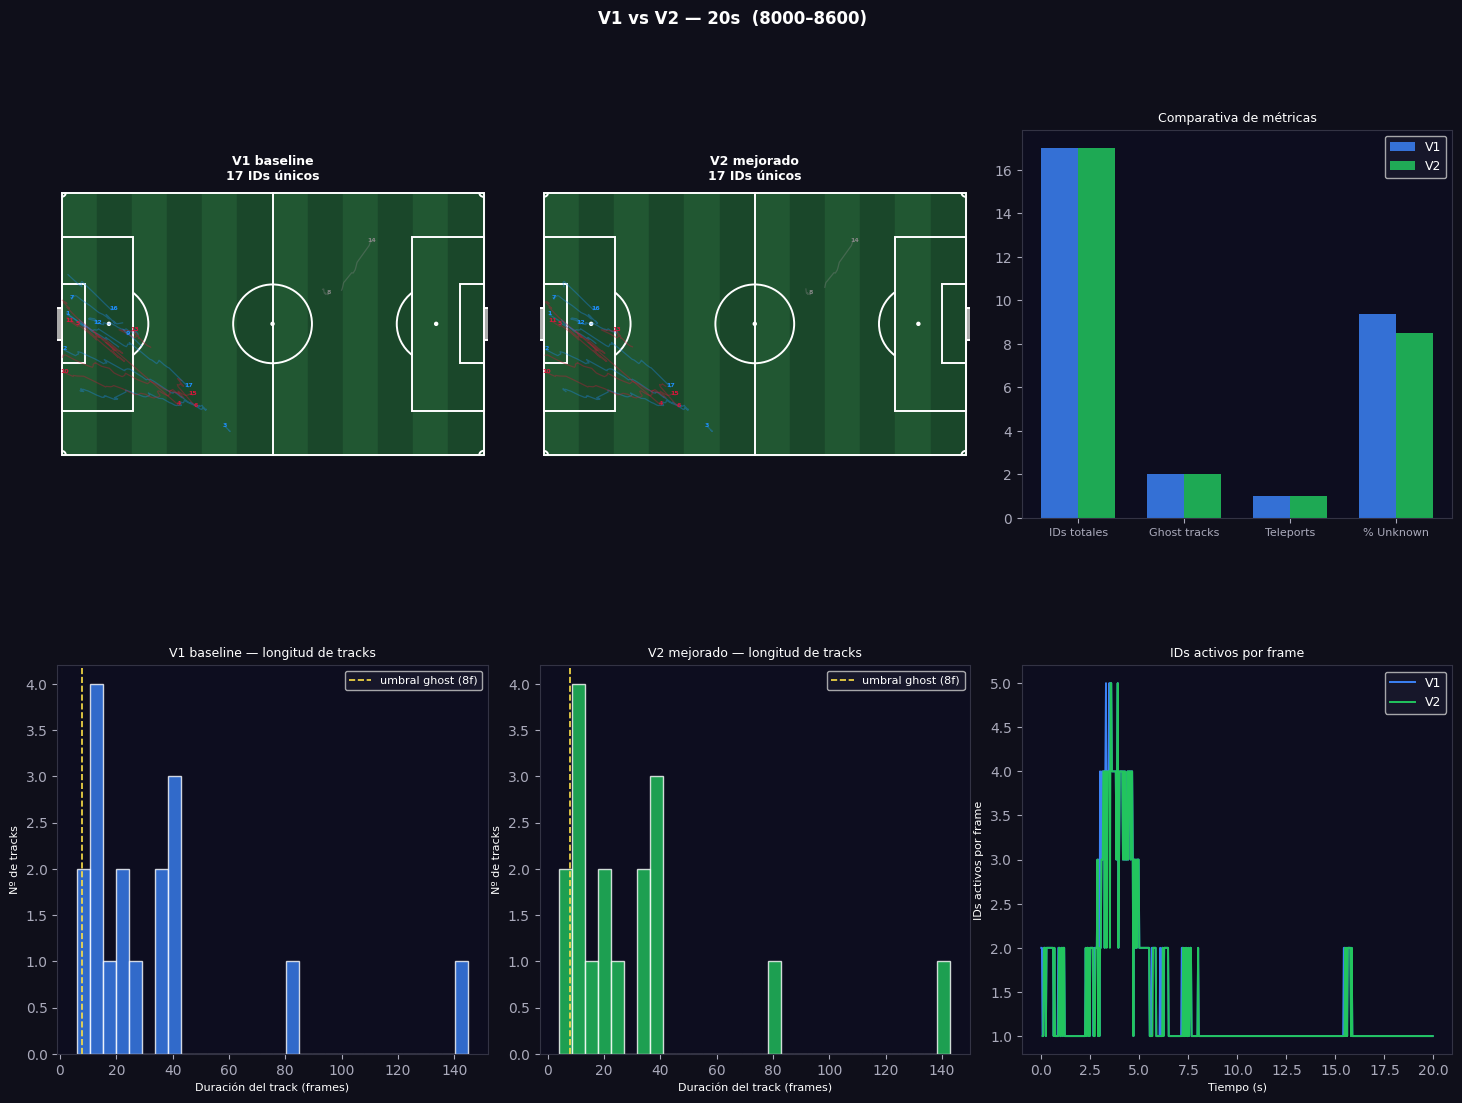

In [ ]:
# ─────────────────────────────────────────────────────
#  Comparación visual: trayectorias + distribuciones
# ─────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 12), facecolor='#0f0f1a')
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.38, wspace=0.12)

# Fila 1: trayectorias en campo
for col, (df, label) in enumerate([(df_v1, 'V1 baseline'), (df_v2, 'V2 mejorado')]):
    ax = fig.add_subplot(gs[0, col])
    draw_pitch_mpl(ax, L_M, A_M)
    if len(df):
        for gid, grp in df.groupby('gid'):
            grp = grp.sort_values('frame')
            if len(grp) < 5: continue
            hex_ = COLOR_MAP_HEX.get(grp.iloc[-1]['cls'], '#aaaaaa')
            ax.plot(grp['x_m'], grp['y_m'], color=hex_, alpha=0.35, lw=0.9, zorder=3)
            ax.text(float(grp['x_m'].iloc[-1]), float(grp['y_m'].iloc[-1]),
                    str(gid), fontsize=4.5, color=hex_, ha='center', zorder=4,
                    fontweight='bold')
    n_ids = df['gid'].nunique() if len(df) else 0
    ax.set_title(f'{label}\n{n_ids} IDs únicos', color='white', fontsize=9, fontweight='bold')

# Fila 1 col 3: barras de métricas
ax_bar = fig.add_subplot(gs[0, 2])
metrics_keys   = ['n_ids', 'n_ghost', 'teleports', 'unknown_pct']
metrics_labels = ['IDs totales', 'Ghost tracks', 'Teleports', '% Unknown']
x     = np.arange(len(metrics_keys)); w = 0.35
vals1 = [m1.get(k, 0) for k in metrics_keys]
vals2 = [m2.get(k, 0) for k in metrics_keys]
ax_bar.bar(x - w/2, vals1, w, label='V1', color='#3b82f6', alpha=0.85)
ax_bar.bar(x + w/2, vals2, w, label='V2', color='#22c55e', alpha=0.85)
ax_bar.set_xticks(x); ax_bar.set_xticklabels(metrics_labels, fontsize=8, color='#aab')
ax_bar.legend(fontsize=9, facecolor='#1a1a2e', labelcolor='white')
ax_bar.set_title('Comparativa de métricas', color='white', fontsize=9)
ax_bar.set_facecolor('#0d0d1f')
for sp in ax_bar.spines.values(): sp.set_color('#334')

# Fila 2: distribución longitud de tracks
for col, (df, label, color) in enumerate([
    (df_v1, 'V1 baseline', '#3b82f6'),
    (df_v2, 'V2 mejorado', '#22c55e'),
]):
    ax = fig.add_subplot(gs[1, col])
    if len(df):
        lens = df.groupby('gid').size().values
        ax.hist(lens, bins=30, color=color, alpha=0.8, edgecolor='#ffffff22')
        ax.axvline(MIN_HITS_GHO, color='#fde047', ls='--', lw=1.2,
                   label=f'umbral ghost ({MIN_HITS_GHO}f)')
        ax.legend(fontsize=8, facecolor='#1a1a2e', labelcolor='white')
    ax.set_xlabel('Duración del track (frames)', fontsize=8)
    ax.set_ylabel('Nº de tracks', fontsize=8)
    ax.set_title(f'{label} — longitud de tracks', color='white', fontsize=9)
    ax.set_facecolor('#0d0d1f')
    for sp in ax.spines.values(): sp.set_color('#334')

# Fila 2 col 3: IDs activos por frame
ax_tl = fig.add_subplot(gs[1, 2])
for df, label, color in [(df_v1,'V1','#3b82f6'), (df_v2,'V2','#22c55e')]:
    if len(df):
        active = df.groupby('frame')['gid'].nunique()
        t_s    = (active.index - START_FRAME) / FPS
        ax_tl.plot(t_s, active.values, color=color, lw=1.4, label=label)
ax_tl.set_xlabel('Tiempo (s)', fontsize=8)
ax_tl.set_ylabel('IDs activos por frame', fontsize=8)
ax_tl.legend(fontsize=9, facecolor='#1a1a2e', labelcolor='white')
ax_tl.set_title('IDs activos por frame', color='white', fontsize=9)
ax_tl.set_facecolor('#0d0d1f')
for sp in ax_tl.spines.values(): sp.set_color('#334')

fig.suptitle(f'V1 vs V2 — {N_FRAMES/FPS:.0f}s  ({START_FRAME}–{END_F})',
             color='white', fontsize=12, fontweight='bold')
plt.tight_layout()
display(fig); plt.close(fig)

Teleportaciones  V1: 1  |  V2: 1


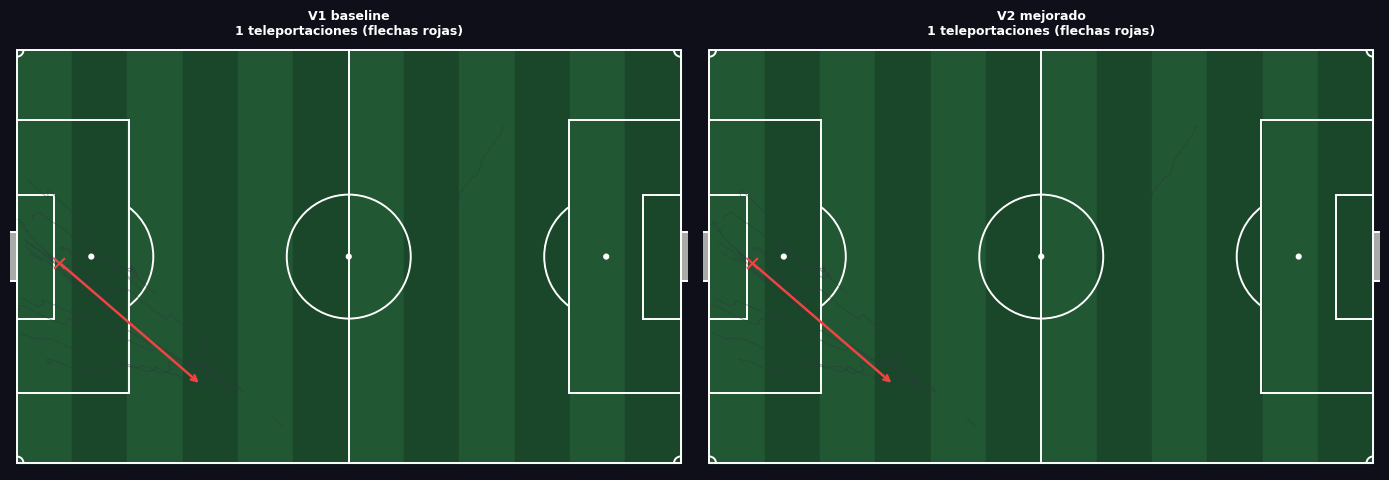

In [ ]:
# ─────────────────────────────────────────────────────
#  Análisis de teleportaciones (proxy de ID switches)
# ─────────────────────────────────────────────────────
def find_teleports(df, thr=TELEPORT_M):
    rows = []
    for gid, grp in df.groupby('gid'):
        grp = grp.sort_values('frame').reset_index(drop=True)
        for i in range(1, len(grp)):
            dx = grp.loc[i,'x_m'] - grp.loc[i-1,'x_m']
            dy = grp.loc[i,'y_m'] - grp.loc[i-1,'y_m']
            d  = float(np.sqrt(dx**2 + dy**2))
            if d > thr:
                rows.append({
                    'gid':        gid,
                    'frame_from': int(grp.loc[i-1,'frame']),
                    'frame_to':   int(grp.loc[i,'frame']),
                    'dist_m':     round(d, 2),
                    'gap_frames': int(grp.loc[i,'frame'] - grp.loc[i-1,'frame']),
                    'cls':        grp.loc[i,'cls'],
                    'x_from': grp.loc[i-1,'x_m'], 'y_from': grp.loc[i-1,'y_m'],
                    'x_to':   grp.loc[i,  'x_m'], 'y_to':   grp.loc[i,  'y_m'],
                })
    return pd.DataFrame(rows)

tp_v1 = find_teleports(df_v1)
tp_v2 = find_teleports(df_v2)
print(f"Teleportaciones  V1: {len(tp_v1)}  |  V2: {len(tp_v2)}")

if len(tp_v1) + len(tp_v2) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), facecolor='#0f0f1a')
    for ax, tp, df, label in [
        (axes[0], tp_v1, df_v1, 'V1 baseline'),
        (axes[1], tp_v2, df_v2, 'V2 mejorado'),
    ]:
        draw_pitch_mpl(ax, L_M, A_M)
        for gid, grp in df.groupby('gid'):
            grp = grp.sort_values('frame')
            if len(grp) < 5: continue
            ax.plot(grp['x_m'], grp['y_m'], color='#334', alpha=0.4, lw=0.7, zorder=2)
        for _, row in tp.iterrows():
            ax.annotate('', xy=(row['x_to'], row['y_to']),
                        xytext=(row['x_from'], row['y_from']),
                        arrowprops=dict(arrowstyle='->', color='#ef4444', lw=1.8),
                        zorder=6)
            ax.scatter([row['x_from']], [row['y_from']], color='#ef4444',
                       s=60, zorder=7, marker='x')
        ax.set_title(f'{label}\n{len(tp)} teleportaciones (flechas rojas)',
                     color='white', fontsize=9, fontweight='bold')
    plt.tight_layout()
    display(fig); plt.close(fig)
else:
    print("Sin teleportaciones en el segmento.")

In [ ]:
# ─────────────────────────────────────────────────────
#  Tuning interactivo de parámetros V2
# ─────────────────────────────────────────────────────
_out_tune = widgets.Output()

_w_max_dist = widgets.FloatSlider(value=V2_MAX_DIST, min=2.0, max=12.0, step=0.5,
    description='max_dist (m):', style={'description_width':'140px'},
    layout=widgets.Layout(width='500px'), continuous_update=False)
_w_window   = widgets.FloatSlider(value=V2_WINDOW_S, min=2.0, max=15.0, step=0.5,
    description='window_s:', style={'description_width':'140px'},
    layout=widgets.Layout(width='500px'), continuous_update=False)
_w_min_hits = widgets.IntSlider(value=V2_MIN_HITS_CONFIRM, min=1, max=10, step=1,
    description='min_hits_confirm:', style={'description_width':'140px'},
    layout=widgets.Layout(width='500px'), continuous_update=False)
_w_hue_w    = widgets.FloatSlider(value=V2_HUE_REID_W, min=0.0, max=12.0, step=0.5,
    description='hue_reid_w:', style={'description_width':'140px'},
    layout=widgets.Layout(width='500px'), continuous_update=False)
_w_gap_hue  = widgets.IntSlider(value=V2_GAP_HUE_FRAMES, min=1, max=30, step=1,
    description='gap_hue_frames:', style={'description_width':'140px'},
    layout=widgets.Layout(width='500px'), continuous_update=False)
_w_class_w  = widgets.FloatSlider(value=V2_CLASS_W, min=0.0, max=15.0, step=0.5,
    description='class_weight:', style={'description_width':'140px'},
    layout=widgets.Layout(width='500px'), continuous_update=False)
_w_run_t    = widgets.Button(description='▶ Re-ejecutar', button_style='primary',
                              layout=widgets.Layout(width='160px'))

def _run_tune(b=None):
    global MIN_HITS_CONFIRM_V2
    MIN_HITS_CONFIRM_V2 = int(_w_min_hits.value)
    tr = KalmanFieldTrackerV2(
        fps=FPS,
        max_dist_m=float(_w_max_dist.value),
        window_s=float(_w_window.value),
        class_weight=float(_w_class_w.value),
        min_hits_confirm=int(_w_min_hits.value),
        hue_reid_w=float(_w_hue_w.value),
        gap_hue=int(_w_gap_hue.value),
    )
    with _out_tune:
        clear_output(wait=True)
        print("Procesando...")
        recs, tr = run_segment(tr, verbose=False)
        df_t = pd.DataFrame(recs)
        m_t  = tracking_metrics(df_t, 'V2 tuned')
        print(f"\n  IDs totales:      {m_t['n_ids']}  (V1={m1['n_ids']})")
        print(f"  Ghost tracks:     {m_t['n_ghost']} ({m_t['ghost_pct']}%)  (V1={m1['n_ghost']})")
        print(f"  Tracks largos:    {m_t['n_long']}  media={m_t['mean_len_long']}f")
        print(f"  Teleportaciones:  {m_t['teleports']}  (V1={m1['teleports']})")
        print(f"  Unknown %:        {m_t['unknown_pct']}%  (V1={m1['unknown_pct']}%)")

        if len(df_t):
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), facecolor='#0f0f1a')
            draw_pitch_mpl(ax1, L_M, A_M)
            for gid, grp in df_t.groupby('gid'):
                if len(grp) < int(_w_min_hits.value): continue
                hex_ = COLOR_MAP_HEX.get(grp.iloc[-1]['cls'], '#aaa')
                ax1.plot(grp['x_m'].sort_values(), grp.sort_values('frame')['y_m'],
                         color=hex_, alpha=0.4, lw=1.0, zorder=3)
            ax1.set_title(f"V2 tuned — {m_t['n_ids']} IDs", color='white', fontsize=9)
            lens = df_t.groupby('gid').size().values
            ax2.hist(lens, bins=25, color='#22c55e', alpha=0.8, edgecolor='#ffffff22')
            ax2.axvline(MIN_HITS_GHO, color='#fde047', ls='--', lw=1.2)
            ax2.set_title('Longitud de tracks', color='white', fontsize=9)
            ax2.set_facecolor('#0d0d1f')
            for sp in ax2.spines.values(): sp.set_color('#334')
            plt.tight_layout()
            display(fig); plt.close(fig)

_w_run_t.on_click(_run_tune)
display(widgets.VBox([
    _w_max_dist, _w_window, _w_min_hits,
    _w_hue_w, _w_gap_hue, _w_class_w,
    _w_run_t, _out_tune,
]))

## Integrar KalmanFieldTrackerV2 en pipeline_core.py

Una vez validado el tracker, hay dos opciones:

**Opción A — Añadir V2 como clase alternativa** (recomendado)  
Copia `_KFTrackV2` y `KalmanFieldTrackerV2` al final de la sección 9 de `pipeline_core.py`.  
En `_process_segment_inner`, cambia:
```python
tracker = KalmanFieldTracker(fps=fps)
```
por:
```python
tracker = KalmanFieldTrackerV2(fps=fps,
    min_hits_confirm=3, hue_reid_w=5.0, gap_hue=8)
```

**Opción B — Pasar parámetros desde config**  
Añade en `config`:
```python
'tracker_version': 'v2',
'min_hits_confirm': 3,
'hue_reid_w': 5.0,
'gap_hue_frames': 8,
```
Y en `process_segment` selecciona el tracker según `config.get('tracker_version')`.

También asegúrate de que `detect_half` pase `hue_sig` en cada detección  
(ya implementado en `_track_half_local` cuando `_use_v3=True`).

In [ ]:
# ─────────────────────────────────────────────────────
#  Resumen final
# ─────────────────────────────────────────────────────
print("\n" + "═"*58)
print("  RESUMEN  V1 baseline  vs  V2 mejorado")
print("═"*58)
rows_summary = [
    ('IDs únicos creados',      'm:n_ids',          '↓'),
    ('Ghost tracks (<8 hits)',   'n_ghost',          '↓'),
    ('% Ghost',                  'ghost_pct',        '↓'),
    ('Tracks largos (≥8 hits)',  'n_long',           '↑'),
    ('Duración media (frames)',  'mean_len_long',    '↑'),
    ('Teleportaciones',          'teleports',        '↓'),
    ('% Unknown',                'unknown_pct',      '↓'),
]
print(f"  {'Métrica':<28} {'V1':>8} {'V2':>8}  {'Δ':>6}  Mejor")
print("  " + "─"*52)
for label, key, direction in rows_summary:
    v1 = m1.get(key, 'N/A'); v2 = m2.get(key, 'N/A')
    try:
        delta = v2 - v1
        ok    = (delta < 0) if direction == '↓' else (delta > 0)
        flag = '' if ok else ('' if delta != 0 else '─')
        ds    = f'{delta:+.1f}' if isinstance(delta, float) else f'{delta:+d}'
    except Exception:
        ds = '─'; flag = '─'
    print(f"  {label:<28} {str(v1):>8} {str(v2):>8}  {ds:>6}  {flag}")
print("═"*58)


══════════════════════════════════════════════════════════
  RESUMEN  V1 baseline  vs  V2 mejorado
══════════════════════════════════════════════════════════
  Métrica                            V1       V2       Δ  Mejor
  ────────────────────────────────────────────────────
  IDs únicos creados                N/A      N/A       ─  ─
  Ghost tracks (<8 hits)              2        2      +0  ─
  % Ghost                          11.8     11.8    +0.0  ─
  Tracks largos (≥8 hits)            15       15      +0  ─
  Duración media (frames)          37.4     35.4    -2.0  ❌
  Teleportaciones                     1        1      +0  ─
  % Unknown                         9.4      8.5    -0.9  ✅
══════════════════════════════════════════════════════════
